<a href="https://colab.research.google.com/github/siccd143/BorrowBoard-YouthxCode/blob/main/model-train.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [14]:
import os, shutil
from roboflow import Roboflow
from torch.utils.data import DataLoader
from ultralytics import YOLO

In [3]:
rf = Roboflow(api_key="86L1iugfIKm488puzmN8")
project = rf.workspace("duc-nguyen-asf36").project("school-supplies-gz456")
version = project.version(1)
dataset = version.download("yolov8")

loading Roboflow workspace...
loading Roboflow project...


In [4]:
#try:
#    model = YOLO('models/yolo26n.pt')
#except:
model = YOLO('yolo26n.pt')
data_yaml_path = os.path.join(project.name.replace(' ', '-') + '-' + str(version.version), 'data.yaml')

In [13]:
results = model.train(data=data_yaml_path, epochs=24, imgsz=640, batch=-1, device=0)

Ultralytics 8.4.80  Python-3.12.10 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 3060, 12288MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=-1, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=school-supplies-1\data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=24, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=runs/detect/train-13/weights/best.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train-14, nbs=64, nms=False, opset=None, optimize=False, optimi

In [15]:
shutil.move(model.export(format="onnx", imgsz=640), "models/yolo26n.onnx")
shutil.move(model.ckpt_path, "models/yolo26n.pt")

Ultralytics 8.4.80  Python-3.12.10 torch-2.5.1+cu121 CPU (11th Gen Intel Core(TM) i5-11400 2.60GHz)
YOLO26n summary (fused): 122 layers, 2,376,786 parameters, 0 gradients, 5.2 GFLOPs

PyTorch: starting from 'F:\BorrowBoard-YouthxCode\runs\detect\train-14\weights\best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 300, 6) (5.1 MB)

ONNX: starting export with onnx 1.22.0 opset 19...


Exporting aten::index operator of advanced indexing in opset 19 is achieved by combination of multiple ONNX operators, including Reshape, Transpose, Concat, and Gather. If indices include negative values, the exported graph will produce incorrect results.


ONNX: slimming with onnxslim 0.1.94...
ONNX: export success  2.0s, saved as 'F:\BorrowBoard-YouthxCode\runs\detect\train-14\weights\best.onnx' (9.4 MB)

Export complete (2.4s)
Results saved to F:\BorrowBoard-YouthxCode\runs\detect\train-14\weights\best.onnx
Predict:         yolo predict task=detect model=F:\BorrowBoard-YouthxCode\runs\detect\train-14\weights\best.onnx imgsz=640 
Validate:        yolo val task=detect model=F:\BorrowBoard-YouthxCode\runs\detect\train-14\weights\best.onnx imgsz=640 data=school-supplies-1\data.yaml  
Visualize:       https://netron.app


'models/yolo26n.pt'


Found https://i.pinimg.com/736x/d0/6b/77/d06b77a50b6c6b113b19ad78f86978cb.jpg locally at d06b77a50b6c6b113b19ad78f86978cb.jpg
image 1/1 f:\BorrowBoard-YouthxCode\d06b77a50b6c6b113b19ad78f86978cb.jpg: 640x448 (no detections), 23.0ms
Speed: 12.3ms preprocess, 23.0ms inference, 0.7ms postprocess per image at shape (1, 3, 640, 448)
Results saved to F:\BorrowBoard-YouthxCode\runs\detect\predict-5


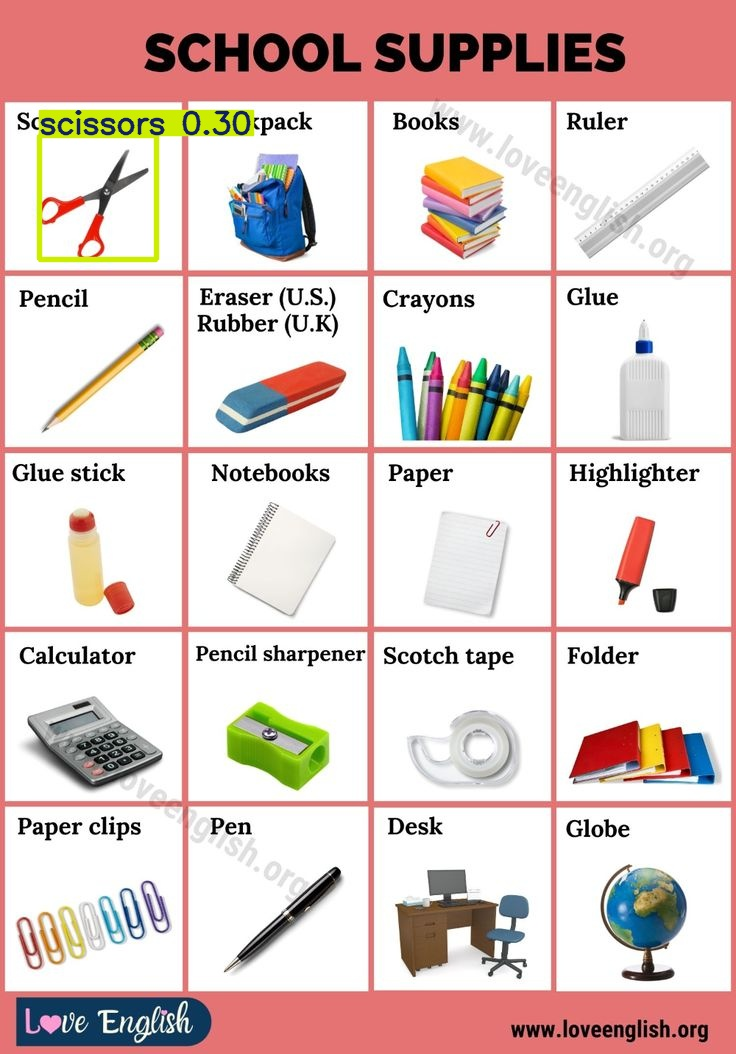

In [16]:
from IPython.display import Image, display

results = model.predict(source='https://i.pinimg.com/736x/d0/6b/77/d06b77a50b6c6b113b19ad78f86978cb.jpg', save=True)
display(Image(filename='runs/detect/predict/d06b77a50b6c6b113b19ad78f86978cb.jpg'))